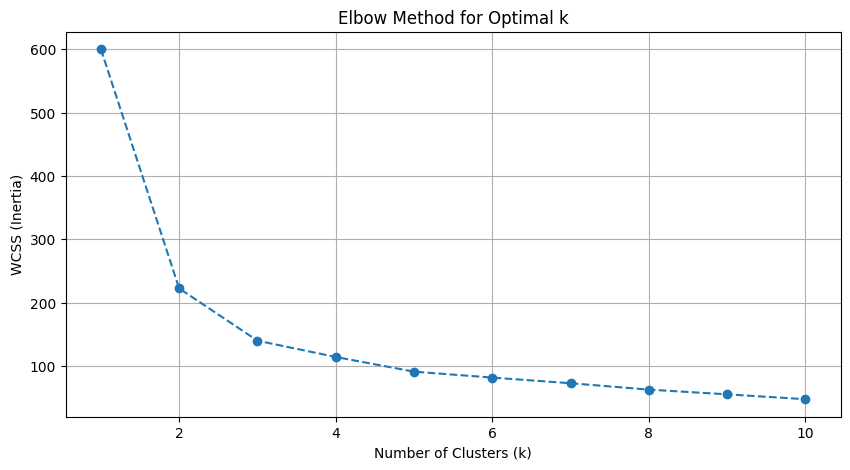

Data with Cluster Assignments (first 10 rows):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0          -0.900681          1.019004          -1.340227         -1.315444   
1          -1.143017         -0.131979          -1.340227         -1.315444   
2          -1.385353          0.328414          -1.397064         -1.315444   
3          -1.506521          0.098217          -1.283389         -1.315444   
4          -1.021849          1.249201          -1.340227         -1.315444   
5          -0.537178          1.939791          -1.169714         -1.052180   
6          -1.506521          0.788808          -1.340227         -1.183812   
7          -1.021849          0.788808          -1.283389         -1.315444   
8          -1.748856         -0.362176          -1.340227         -1.315444   
9          -1.143017          0.098217          -1.283389         -1.447076   

   cluster  
0        1  
1        1  
2        1  
3        1  
4        1  
5    

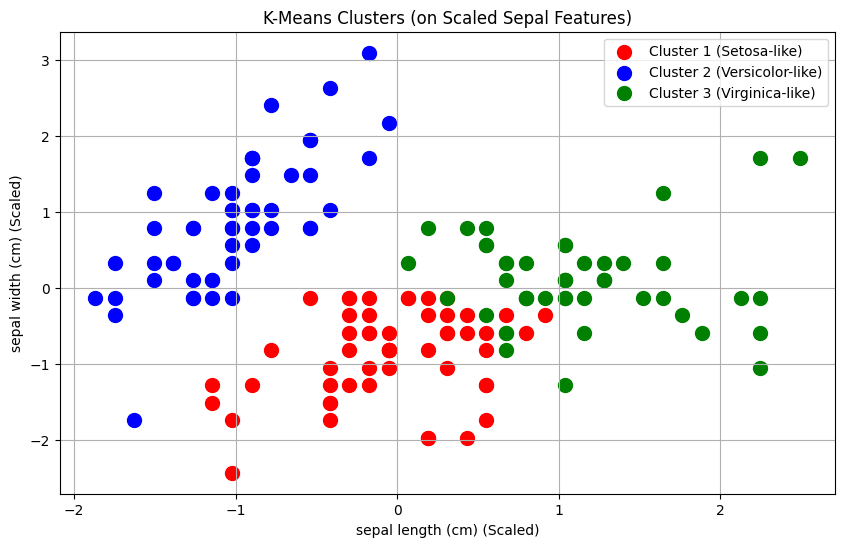

In [2]:
# --- Step 1: Import Required Libraries ---
# (from exp 9.pdf, Cell 1)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

# --- Step 2: Load Dataset ---
# (from exp 9.pdf, Cell 2)
iris = load_iris()
X = iris.data
# Note: y (target) is not used, as this is unsupervised learning

# --- Step 3: Feature Scaling ---
# (from exp 9.pdf, Cell 3)
# K-Means is distance-based, so scaling is important
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Step 4: Implement the Elbow Method ---
# (from exp 9.pdf, Cell 6)
# WCSS = Within-Cluster Sum of Squares (Inertia)
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init="k-means++", max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# --- Step 5: Plot the Elbow Method Graph ---
# (from exp 9.pdf, Cell 7)
plt.figure(figsize=(10, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

# --- Step 6: Train Final K-Means Model ---
# (from exp 9.pdf, Cell 8, 9, 10)
# The elbow plot (Cell 7) shows a clear bend at k=3
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init="k-means++", max_iter=300, n_init=10, random_state=42)

# --- Step 7: Get Cluster Predictions ---
# (from exp 9.pdf, Cell 11)
y_kmeans = kmeans.fit_predict(X_scaled)

# Add cluster labels to a DataFrame for inspection (optional, based on Cell 15)
df = pd.DataFrame(data=X_scaled, columns=iris.feature_names)
df['cluster'] = y_kmeans
print("Data with Cluster Assignments (first 10 rows):")
print(df.head(10))

# --- Step 8: Visualize the Clusters ---
# (from exp 9.pdf, Cell 16)
# This visualization plots the first two features:
# 'sepal length (cm)' vs 'sepal width (cm)'
plt.figure(figsize=(10, 6))

# Plot clusters
plt.scatter(X_scaled[y_kmeans == 0, 0], X_scaled[y_kmeans == 0, 1], s=100, c='red', label='Cluster 1 (Setosa-like)')
plt.scatter(X_scaled[y_kmeans == 1, 0], X_scaled[y_kmeans == 1, 1], s=100, c='blue', label='Cluster 2 (Versicolor-like)')
plt.scatter(X_scaled[y_kmeans == 2, 0], X_scaled[y_kmeans == 2, 1], s=100, c='green', label='Cluster 3 (Virginica-like)')

# Plot centroids
# Note: The document's plot (Cell 16) does not show centroids,
# but they are often included in K-Means plots.
# We will stick to the document's visualization.

plt.title('K-Means Clusters (on Scaled Sepal Features)')
plt.xlabel(iris.feature_names[0] + ' (Scaled)')
plt.ylabel(iris.feature_names[1] + ' (Scaled)')
plt.legend()
plt.grid(True)
plt.show()